In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

short_names = [
    "D2A","D2C","D2N","D2R","D2E",
    "Y9E","Y9G","Y9Q","Y9R","Y9V",
    "T7V","T7Q","T7R","T7Y"
]

def read_colvar(p):
    with open(p) as f:
        for line in f:
            if line.startswith("#!"):
                toks = line.strip().split()
                cols = toks[2:] if len(toks)>2 and toks[1]=="FIELDS" else toks[1:]
                break
    names = cols if cols[0]=="time" else ["time"]+cols
    return pd.read_csv(p, sep=r"\s+", comment="#", names=names)

def collect_lda_coeffs(base: Path, short_names):
    wt_F = read_colvar(base/"COLVAR_F_FILTERED_WT")
    wt_UF = read_colvar(base/"COLVAR_UF_FILTERED_WT")
    features = wt_F.columns.drop("time")
    rows = []
    for short in short_names:
        mut_F = read_colvar(base/short/"COLVAR_F_filtered")
        mut_UF = read_colvar(base/short/"COLVAR_UF_filtered")

        Xf = pd.concat([mut_F[features], wt_F[features]], ignore_index=True)
        yf = np.array([0]*len(mut_F) + [1]*len(wt_F))
        lda_f = LDA(priors=[0.5, 0.5]).fit(Xf, yf)
        wf = lda_f.coef_[0]
        wf = wf / (np.linalg.norm(wf) + 1e-12)

        Xu = pd.concat([mut_UF[features], wt_UF[features]], ignore_index=True)
        yu = np.array([0]*len(mut_UF) + [1]*len(wt_UF))
        lda_u = LDA(priors=[0.5, 0.5]).fit(Xu, yu)
        wu = lda_u.coef_[0]
        wu = wu / (np.linalg.norm(wu) + 1e-12)

        for j, feat in enumerate(features):
            rows.append((short, j, feat, wf[j], wu[j]))

    return pd.DataFrame(rows, columns=["Mutant","Order","Feature","Coef_F","Coef_UF"])

base = Path("../data/mur_trajectories")
coef_df = collect_lda_coeffs(base, short_names)


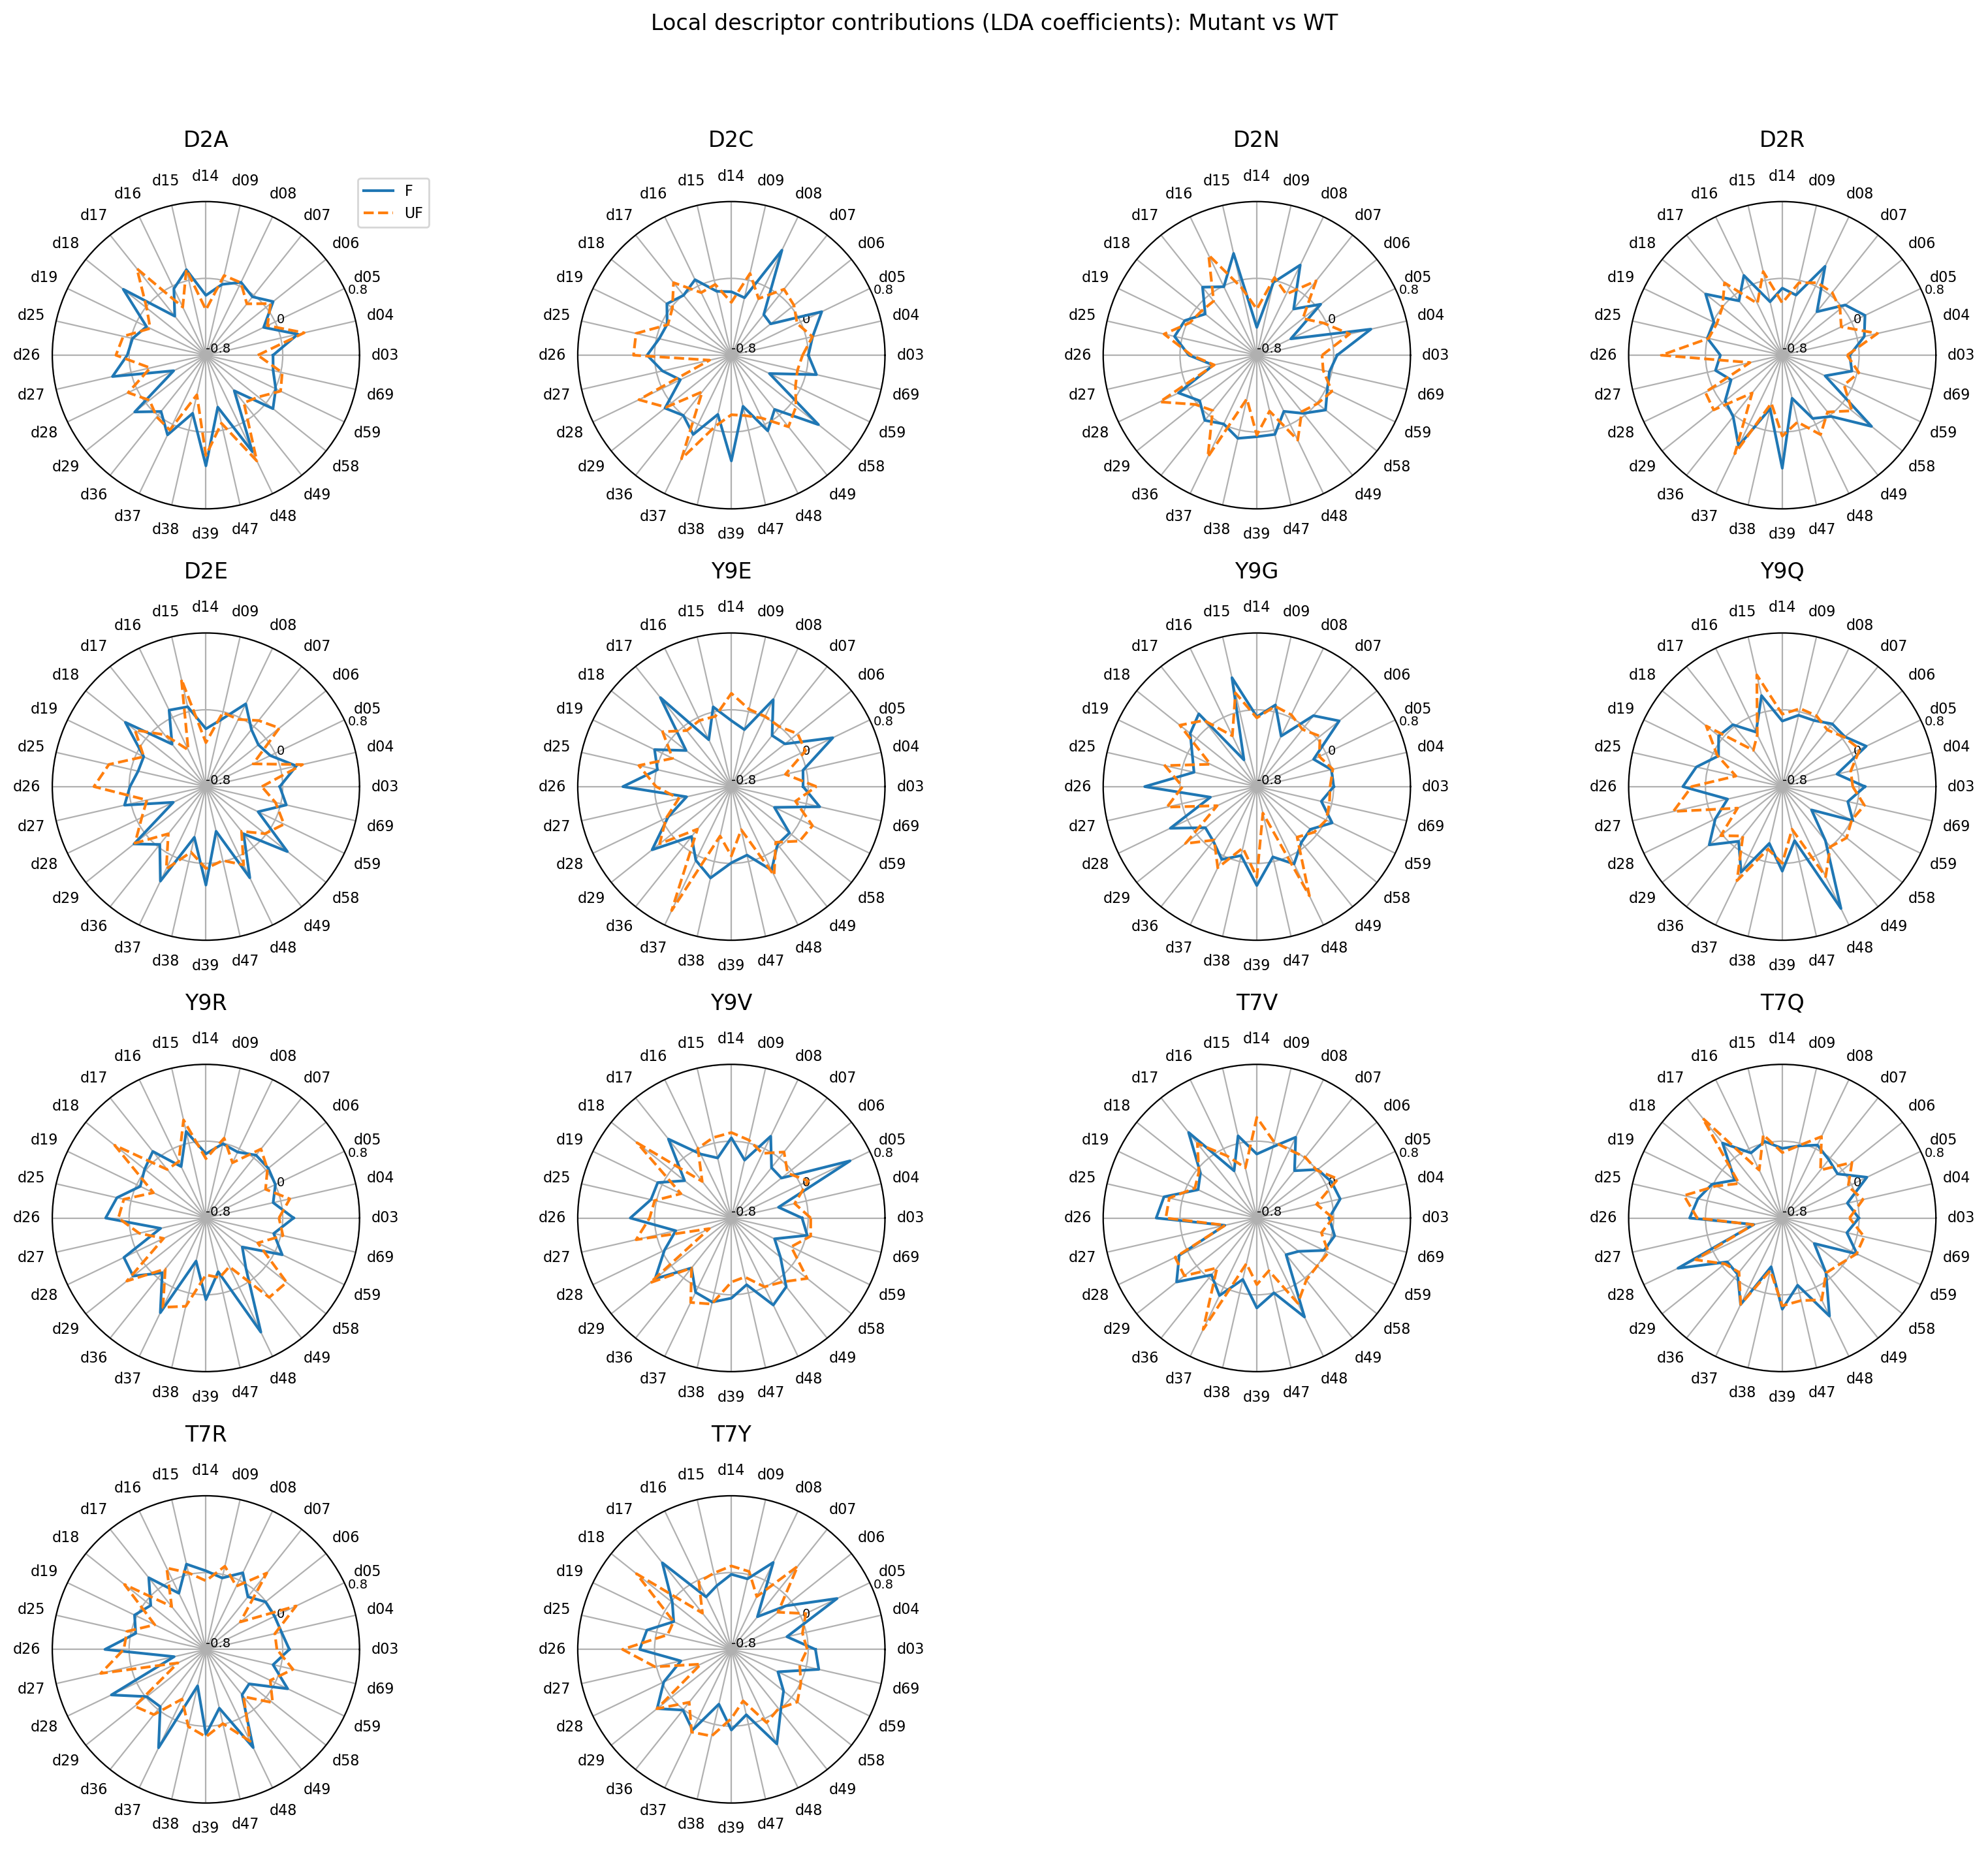

In [37]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd

def _canonical_orders(coef_df: pd.DataFrame):
    muts = coef_df["Mutant"].unique().tolist()
    first = muts[0]
    feats = (coef_df[coef_df["Mutant"]==first]
             .sort_values("Order")["Feature"].tolist())
    return muts, feats

def plot_radar(coef_df: pd.DataFrame, cols=4):
    muts, feats = _canonical_orders(coef_df)
    n = len(muts)
    rows = (n + cols - 1)//cols
    plt.figure(figsize=(4*cols, 3.6*rows), dpi=200)
    ang = np.linspace(0, 2*np.pi, len(feats), endpoint=False)
    for i, m in enumerate(muts, 1):
        sub = (coef_df[coef_df.Mutant==m]
               .set_index("Feature")
               .loc[feats])
        v1 = sub["Coef_F"].to_numpy()
        v2 = sub["Coef_UF"].to_numpy()
        ax = plt.subplot(rows, cols, i, projection='polar')
        ax.plot(np.r_[ang, ang[0]], np.r_[v1, v1[0]], label='F')
        ax.plot(np.r_[ang, ang[0]], np.r_[v2, v2[0]], linestyle='--', label='UF')
        ax.set_xticks(ang)
        ax.set_xticklabels(feats, fontsize=8)
        ax.set_title(m, pad=12)
        ax.set_ylim(-0.8, 0.8)
        ax.set_yticks([-0.8, 0, 0.8])
        ax.set_yticklabels(["-0.8","0","0.8"], fontsize=7)  
        ax.grid(True)
        if i==1:
            ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=8)
    plt.suptitle('Local descriptor contributions (LDA coefficients): Mutant vs WT', y=0.98)
    plt.tight_layout(rect=(0,0,1,0.95))
    plt.show()



plot_radar(coef_df)
# plot_heatmap(coef_df, which="Coef_UF")


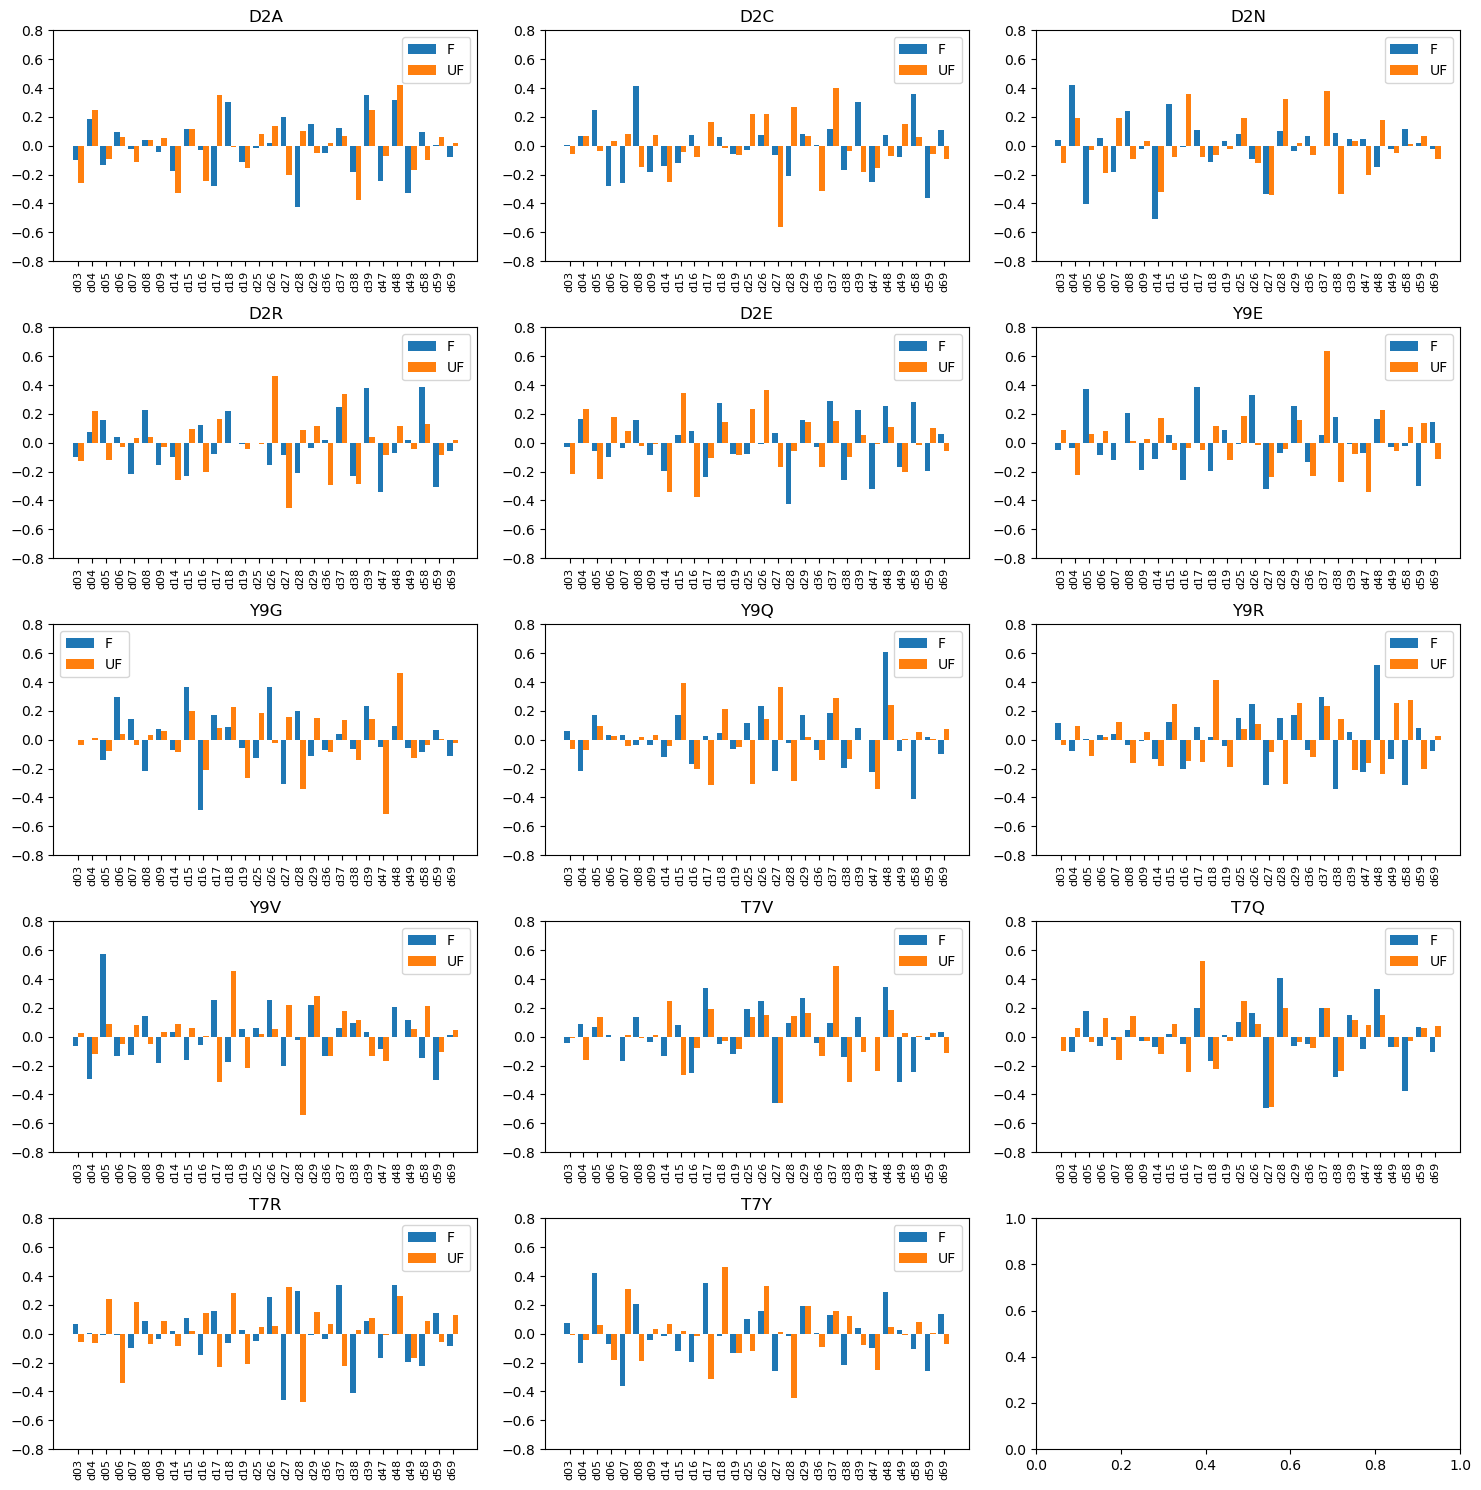

In [ ]:
def plot_bar(coef_df, ncols=3):
    muts = coef_df["Mutant"].unique()
    nrows = (len(muts)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), squeeze=False, dpi=200)
    for ax, m in zip(axes.ravel(), muts):
        sub = coef_df[coef_df.Mutant==m].sort_values("Order")
        x = np.arange(len(sub))
        ax.bar(x-0.2, sub["Coef_F"], width=0.4, label="F")
        ax.bar(x+0.2, sub["Coef_UF"], width=0.4, label="UF")
        ax.set_xticks(x)
        ax.set_xticklabels(sub["Feature"], rotation=90, fontsize=8)
        ax.set_title(m)
        ax.set_ylim(-0.8, 0.8)  
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_bar(coef_df, ncols=3)
